# lgbm_3class_xfn5d_35f — Training & Hyperparameter Tuning

**Purpose**: Fully self-contained notebook that:
1. Loads the dataset and defines all constants (features, target, folds)
2. Runs a walk-forward hyperparameter search over the key LightGBM parameters
3. Selects the best configuration using a composite score (ASA + F1)
4. Trains the final "production" model on all available data with the best params
5. Saves a new dated artifact — **does not overwrite** the previous locked artifact

> The performance & SHAP analysis notebook (`lgbm_3class_xfn5d_35f_performance_and_shap.ipynb`)
> loads this artifact to run the 7-fold walk-forward evaluation.

**Model**: `lgbm_3class_xfn5d_35f`  
**Features**: 35 (30 base event-style + market/macro + 5 TA additions: `td_rsqr_60d`, `td_wvma_5d`, `td_wvma_20d`, `td_corr_pv_5d`, `td_beta_20d`)


In [1]:
import sys, json, pickle, warnings
from pathlib import Path
from datetime import date
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT         = NOTEBOOK_DIR.parents[1]          # project root
EXP_PARENT   = ROOT / 'step3_predictive_model/model_experiments'
ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT         : {ROOT}')
print(f'Artifact dir : {ARTIFACT_DIR}')

ROOT         : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/final_model/artifacts


## 1. Dataset & Constants

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset : {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')

Dataset : 1285 rows  |  2021-02-25 → 2026-04-09


In [3]:
# ── Define 35f feature set (30 base + 5 TA additions) ───────────────────────
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

BASE_FEATURES_30 = [
    'td_return_5d', 'td_return_20d', 'td_volatility_20d', 'td_vs_xfn_5d', 'td_vs_tsx_5d',
    'td_corr_pv_20d', 'td_volume_change_20d', 'td_dist_52w_high',
    'yield_curve_slope', 'yield_10y_level',
    'vix_volatility_20d', 'dxy_level', 'gold_level', 'fx_usdcad_level',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_ceo_tone', 'evt_cfo_tone', 'evt_framing_gap', 'evt_aml_pressure', 'evt_aml_shift',
    'evt_guidance_strength', 'evt_guidance_shift', 'evt_macro_topic',
    'evt_topic_entropy', 'evt_news_tone', 'evt_news_flow',
]

TA_ADDITIONS = ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d', 'td_corr_pv_5d', 'td_beta_20d']

FEATURES  = BASE_FEATURES_30 + TA_ADDITIONS
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
label_map = {-1: 0, 0: 1, 1: 2}
inv_map   = {0: -1, 1: 0, 2: 1}

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing features: {missing}'

print(f'Features  : {len(FEATURES)} (30 base + {len(TA_ADDITIONS)} TA)')
print(f'Target    : {TARGET}')
print(f'Threshold : ±{THRESHOLD*100:.2f}%')
print(f'Folds     : {len(E10_FOLDS)}')
print()
print('TA additions:', TA_ADDITIONS)


Features  : 35 (30 base + 5 TA)
Target    : target_excess_xfn_5d
Threshold : ±0.30%
Folds     : 7

TA additions: ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d', 'td_corr_pv_5d', 'td_beta_20d']


## 2. Helper Functions

In [4]:
def offset_metrics(preds, y_true_cls, y_true_cont, dates):
    """Stride-5 offset-averaged metrics.
    active_asa uses continuous excess return (signal-detector definition).
    """
    rows = []
    for off in OFFSETS:
        idx    = np.arange(off, len(dates), STRIDE)
        p      = preds[idx]
        y_cls  = y_true_cls[idx]
        y_cont = y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()


def fit_with_params(train_df, test_df, params: dict):
    """Train LightGBM with given params and return predictions + labels."""
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **params
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds_enc = clf.predict(x_te)
    preds     = np.array([inv_map[p] for p in preds_enc])
    return clf, preds, y_te_cls, y_te_cont


print('Helper functions defined.')

Helper functions defined.


## 3. Hyperparameter Search

Sweep the three parameters most sensitive to dataset size.  
All others are held at their informed defaults.

| Param | Values | Default |
|---|---|---|
| `num_leaves` | 4, 8, 16, 31 | 8 |
| `min_child_samples` | 20, 40, 60 | 40 |
| `n_estimators` | 80, 120, 200 | 120 |

**Selection criterion** (primary): composite score = `0.6 × active_asa + 0.4 × macro_f1`  
This balances directional signal quality (primary) with balanced class prediction (secondary).

In [5]:
BASE_PARAMS = dict(
    learning_rate=0.05, feature_fraction=0.8,
    reg_alpha=0.2, reg_lambda=1.0,
)

GRID = {
    'num_leaves':        [4, 8, 16, 31],
    'min_child_samples': [20, 40, 60],
    'n_estimators':      [80, 120, 200],
}

combos = list(iterproduct(
    GRID['num_leaves'], GRID['min_child_samples'], GRID['n_estimators']
))
print(f'Running {len(combos)} configs × {len(E10_FOLDS)} folds …\n')

search_rows = []
for i, (nl, mcs, ne) in enumerate(combos, 1):
    params = {**BASE_PARAMS, 'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne}
    fold_ms = []
    for fold_id, train_end, test_start, test_end in E10_FOLDS:
        tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
        te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
                   (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
        _, preds, y_cls, y_cont = fit_with_params(df[tr_mask], df[te_mask], params)
        fold_ms.append(offset_metrics(preds, y_cls, y_cont, df[te_mask]['date'].values))

    agg  = pd.DataFrame(fold_ms).mean()
    comp = 0.6 * float(agg.active_asa) + 0.4 * float(agg.macro_f1)
    search_rows.append({
        'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne,
        'mean_acc':   round(float(agg.mean_acc),   3),
        'macro_f1':   round(float(agg.macro_f1),   3),
        'active_asa': round(float(agg.active_asa),  3),
        'active_cov': round(float(agg.active_cov),  3),
        'composite':  round(comp, 4),
    })
    print(f'[{i:2d}/36]  leaves={nl:2d}  mcs={mcs:2d}  ne={ne:3d}  '
          f'asa={agg.active_asa:.3f}  f1={agg.macro_f1:.3f}  composite={comp:.4f}')

print('\nSearch complete.')

Running 36 configs × 7 folds …



[ 1/36]  leaves= 4  mcs=20  ne= 80  asa=0.573  f1=0.322  composite=0.4729


[ 2/36]  leaves= 4  mcs=20  ne=120  asa=0.574  f1=0.332  composite=0.4774


[ 3/36]  leaves= 4  mcs=20  ne=200  asa=0.570  f1=0.317  composite=0.4686


[ 4/36]  leaves= 4  mcs=40  ne= 80  asa=0.605  f1=0.347  composite=0.5018


...

[32/36]  leaves=31  mcs=40  ne=120  asa=0.576  f1=0.335  composite=0.4797


[33/36]  leaves=31  mcs=40  ne=200  asa=0.577  f1=0.338  composite=0.4814


[34/36]  leaves=31  mcs=60  ne= 80  asa=0.546  f1=0.305  composite=0.4493


[35/36]  leaves=31  mcs=60  ne=120  asa=0.553  f1=0.323  composite=0.4612


[36/36]  leaves=31  mcs=60  ne=200  asa=0.561  f1=0.333  composite=0.4698

Search complete.


## 4. Results & Best Configuration

In [6]:
search_df = (
    pd.DataFrame(search_rows)
    .sort_values('composite', ascending=False)
    .reset_index(drop=True)
)
search_df.index += 1

print('=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===\n')
display(search_df[['num_leaves','min_child_samples','n_estimators',
                    'active_asa','macro_f1','mean_acc','active_cov','composite']])

best_row  = search_df.iloc[0]
BEST_PARAMS = {
    **BASE_PARAMS,
    'num_leaves':        int(best_row.num_leaves),
    'min_child_samples': int(best_row.min_child_samples),
    'n_estimators':      int(best_row.n_estimators),
}

print(f'\n── Best configuration (rank 1 by composite) ──')
for k, v in BEST_PARAMS.items():
    print(f'  {k}: {v}')
print(f'\n  ASA       : {best_row.active_asa:.3f}')
print(f'  Macro F1  : {best_row.macro_f1:.3f}')
print(f'  Mean acc  : {best_row.mean_acc:.3f}')
print(f'  Composite : {best_row.composite:.4f}')

=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===



,num_leaves,min_child_samples,n_estimators,active_asa,macro_f1,mean_acc,active_cov,composite
1,4,40,80,0.605,0.347,0.482,0.968,0.5018
2,4,40,200,0.601,0.352,0.462,0.903,0.5015
3,4,40,120,0.597,0.350,0.474,0.943,0.4980
4,4,60,200,0.596,0.349,0.456,0.912,0.4970
5,8,40,120,0.590,0.340,0.457,0.922,0.4902
6,8,40,80,0.590,0.339,0.461,0.936,0.4899
7,8,40,200,0.581,0.337,0.449,0.912,0.4833
8,8,20,80,0.580,0.336,0.454,0.915,0.4825
9,31,40,200,0.577,0.338,0.435,0.906,0.4814
10,8,20,120,0.581,0.329,0.444,0.904,0.4802



── Best configuration (rank 1 by composite) ──
  learning_rate: 0.05
  feature_fraction: 0.8
  reg_alpha: 0.2
  reg_lambda: 1.0
  num_leaves: 4
  min_child_samples: 40
  n_estimators: 80

  ASA       : 0.605
  Macro F1  : 0.347
  Mean acc  : 0.482
  Composite : 0.5018


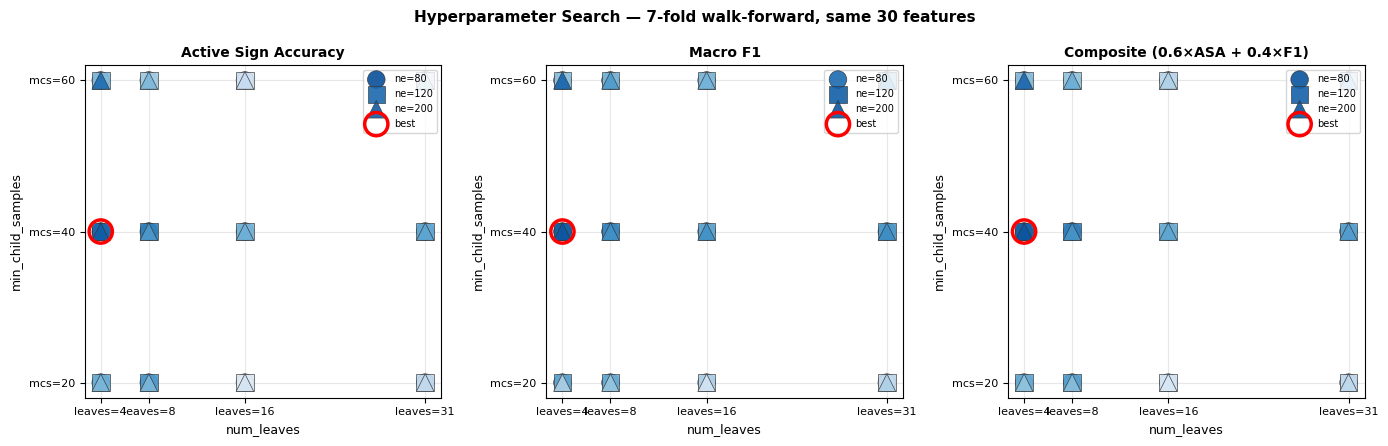

In [ ]:
# ── Bubble chart: composite score across the grid ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ne_vals  = GRID['n_estimators']
colors   = ['#4a7cf6', '#f0a500', '#e55a5a']
markers  = ['o', 's', '^']

for ax, (metric, label) in zip(axes, [
    ('active_asa', 'Active Sign Accuracy'),
    ('macro_f1',   'Macro F1'),
    ('composite',  'Composite (0.6×ASA + 0.4×F1)'),
]):
    for ne, color, marker in zip(ne_vals, colors, markers):
        sub = search_df[search_df.n_estimators == ne]
        ax.scatter(sub.num_leaves, sub.min_child_samples,
                   s=160, c=sub[metric], cmap='Blues',
                   vmin=search_df[metric].min()-0.01,
                   vmax=search_df[metric].max()+0.01,
                   marker=marker, edgecolors='#333', linewidths=0.5,
                   label=f'ne={ne}', alpha=0.9, zorder=3)

    # highlight best
    ax.scatter(int(best_row.num_leaves), int(best_row.min_child_samples),
               s=280, c='none', edgecolors='red', linewidths=2.5,
               zorder=4, label='best')

    ax.set_xticks(GRID['num_leaves'])
    ax.set_xticklabels([f'leaves={v}' for v in GRID['num_leaves']], fontsize=8)
    ax.set_yticks(GRID['min_child_samples'])
    ax.set_yticklabels([f'mcs={v}' for v in GRID['min_child_samples']], fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('num_leaves', fontsize=9)
    ax.set_ylabel('min_child_samples', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Search — 7-fold walk-forward, same 35 features',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train Final Model & Save Artifact

Train on **all available data** (the full dataset up to the last available date)
using the best hyperparameters. This is the "production" model — the one you
would use to generate forward-looking signals on new data.

The 7-fold walk-forward evaluation (done in the performance notebook) uses the
same hyperparameters but trains each fold incrementally to avoid look-ahead.

In [8]:
# ── Train on all available non-null target rows ───────────────────────────────
full_df    = df[df[TARGET].notna()].copy()
train_end  = full_df['date'].max()

x_full = full_df[FEATURES].fillna(full_df[FEATURES].median())
y_full = label_3class(full_df[TARGET].values, threshold=THRESHOLD)
y_enc  = np.array([label_map[v] for v in y_full], dtype=int)

final_clf = lgb.LGBMClassifier(
    objective='multiclass', num_class=3,
    random_state=42, verbose=-1, n_jobs=1,
    **BEST_PARAMS,
)
final_clf.fit(x_full, y_enc)

print(f'Trained on : {len(full_df)} rows')
print(f'Date range : {full_df["date"].min().date()} → {train_end.date()}')
print(f'Params     : {BEST_PARAMS}')
print('Training complete ✓')

Trained on : 1285 rows
Date range : 2021-02-25 → 2026-04-09
Params     : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 4, 'min_child_samples': 40, 'n_estimators': 80}
Training complete ✓


## 6. Save Artifact

In [9]:
TODAY       = date.today().isoformat()     # e.g. 2026-04-22
ARTIFACT_ID = f'lgbm_3class_xfn5d_35f_tuned-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

# ── PKL ───────────────────────────────────────────────────────────────────────
artifact = {
    'model':              final_clf,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          label_map,
    'inverse_label_map':  inv_map,
    'best_params':        BEST_PARAMS,
    'train_rows':         len(full_df),
    'train_end':          str(train_end.date()),
    'artifact_id':        ARTIFACT_ID,
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

# ── JSON metadata ─────────────────────────────────────────────────────────────
meta = {
    'artifact_id':     ARTIFACT_ID,
    'model_name':      'lgbm_3class_xfn5d_35f',
    'artifact_type':   'tuned',
    'created':         TODAY,
    'source':          'lgbm_3class_xfn5d_35f_training.ipynb',
    'description':     (
        'LightGBM 3-class signal model (outperform / neutral / underperform vs XFN). '
        'Hyperparameters selected via 36-config × 7-fold walk-forward search, '
        'composite score = 0.6×ASA + 0.4×F1. '
        'Production model trained on all available data.'
    ),
    'best_params':     BEST_PARAMS,
    'search_winner':   {
        'active_asa':  float(best_row.active_asa),
        'macro_f1':    float(best_row.macro_f1),
        'composite':   float(best_row.composite),
        'rank':        1,
    },
    'features':        FEATURES,
    'n_features':      len(FEATURES),
    'target':          TARGET,
    'threshold':       THRESHOLD,
    'train_rows':      int(len(full_df)),
    'train_end':       str(train_end.date()),
    'artifact_path':   str(PKL_PATH),
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved PKL  : {PKL_PATH.name}')
print(f'Saved JSON : {JSON_PATH.name}')
print()
print('Existing artifacts in folder:')
for p in sorted(ARTIFACT_DIR.glob('*.pkl')):
    tag = '  ← original locked' if 'tuned' not in p.name else '  ← new tuned'
    print(f'  {p.name}{tag}')


Saved PKL  : lgbm_3class_xfn5d_35f_tuned-2026-04-22.pkl
Saved JSON : lgbm_3class_xfn5d_35f_tuned-2026-04-22.json

Existing artifacts in folder:
  lgbm_3class_xfn5d_35f_tuned-2026-04-22.pkl  ← new tuned
